# Capstone — CTR / Engagement Opportunity Scoring

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdeenMir/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Research question:** Can a model rank pages that are more likely to be observed as declining, while improving on the transparent Week-4 CTR baseline, without leaking the outcome into the features?

This notebook is the reproducible analysis behind the deployed paper. It uses the repository's public-safe anonymized dataset and keeps the target, split, baseline, metrics, and limitations explicit.


## 1. Question

The decision is **which pages should an editor review first** for possible engagement/CTR improvement. The unit of analysis is a content page. The output is a ranked score, not an automatic editorial decision.

The capstone evaluates whether a learned ranking can distinguish pages labeled as declining better than the transparent Week-4 baseline. The target is `is_declining_label = (trend_direction == "down")`; it is deliberately **not** the hand-written CTR-gap rule, because training a model to reproduce that rule would be circular.

A wrong high-priority call costs reviewer time; a missed opportunity costs a chance to investigate a page. The model is therefore decision support, not a claim about Google's ranking algorithm or a causal intervention.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOCAL_PATH = "../../data/raw/content_refresh_anonymized.csv"
RAW_URL = "https://raw.githubusercontent.com/AdeenMir/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
RUNNING_LOCAL = os.path.exists(LOCAL_PATH)
OUTPUT_DIR = "../outputs" if RUNNING_LOCAL else "work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(LOCAL_PATH if RUNNING_LOCAL else RAW_URL)

df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)

for col in ["search_volume", "competition", "cpc", "word_count", "char_count"]:
    df[f"has_{col}"] = df[col].notna().astype(int)

for col in ["impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d"]:
    df[f"log_{col}"] = np.log1p(df[col])

NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "log_impressions_90d", "log_clicks_90d", "log_sessions_90d", "log_ai_sessions_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct",
    "has_search_volume", "has_competition", "has_cpc", "has_word_count", "has_char_count",
]
CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier",
]

for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna("unknown").astype(str)

X = pd.get_dummies(
    df[NUMERIC_FEATURES + CATEGORICAL_FEATURES],
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)
y = df["is_declining_label"]

print(f"Rows: {len(df):,}")
print(f"Overall declining base rate: {y.mean():.3f}")
print(f"Feature matrix: {X.shape}")
print("Leakage columns present in X:", "trend_direction" in X.columns, "trend_pct" in X.columns)


Rows: 30,000
Overall declining base rate: 0.542
Feature matrix: (30000, 49)
Leakage columns present in X: False False


## 2. Data

The analysis uses the repository's anonymized content-refresh dataset. It is a single trailing-90-day snapshot per page, so the validation design is grouped by client rather than time-aware.

The following are deliberately excluded from the feature matrix:

- `trend_direction` and `trend_pct`: the outcome itself.
- `impressions_last_30d`, `impressions_prev_30d`, `clicks_last_30d`, `clicks_prev_30d`, `sessions_last_30d`, `sessions_prev_30d`: direct inputs to the observed trend calculation and therefore leakage by another name.
- `client_id`: grouping key only, never a predictive feature.
- `content_id`: identifier only, never a predictive feature.

Missingness flags are retained for selected content fields because missingness is informative of content type in the data dictionary; numeric values are then imputed with zero and categoricals with `unknown`.


In [2]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["client_id"]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]

overlap = set(df_train["client_id"]) & set(df_test["client_id"])

print(f"Train rows: {len(X_train):,} ({y_train.mean():.3f} positive rate)")
print(f"Test rows:  {len(X_test):,} ({y_test.mean():.3f} positive rate)")
print(f"Clients in both train and test: {len(overlap)}")
print(f"Distinct clients — train: {df_train['client_id'].nunique()}, test: {df_test['client_id'].nunique()}")
assert len(overlap) == 0


Train rows: 19,166 (0.532 positive rate)
Test rows:  10,834 (0.559 positive rate)
Clients in both train and test: 0
Distinct clients — train: 22, test: 10


## 3. Methodology

The baseline is the Week-4 rule: compare CTR with the median CTR expected for the page's position tier, require at least 500 impressions in 90 days, and combine the positive CTR gap with an exposure rank.

The baseline's tier medians are fitted on **training rows only** before scoring the test set. This makes the comparison fair.

Three models are compared:

1. Logistic regression — a readable linear reference.
2. Depth-4 decision tree — a small, human-readable rule model.
3. Random forest — retained only if its performance earns the extra complexity.

The main metrics are ROC AUC, average precision, and precision@50. The test-set base rate is reported alongside precision@50 because the positive class is already common.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 42
VOLUME_FLOOR = 500

train_reliable = df_train[
    (df_train["avg_position"] > 0) &
    (df_train["impressions_90d"] >= VOLUME_FLOOR)
]
expected_ctr_by_tier = train_reliable.groupby("position_tier")["ctr"].median()

def baseline_score(frame):
    has_pos = frame["avg_position"] > 0
    expected = frame["position_tier"].map(expected_ctr_by_tier)
    gap = (expected - frame["ctr"]).clip(lower=0).where(has_pos, 0)

    meets_floor = has_pos & (frame["impressions_90d"] >= VOLUME_FLOOR)

    lo, hi = gap.min(), gap.max()
    normalized_gap = (gap - lo) / (hi - lo) if hi > lo else gap * 0
    exposure_rank = frame["impressions_90d"].rank(method="average", pct=True).fillna(0)
    score = normalized_gap * exposure_rank

    return np.where(meets_floor, score, 0.0)

baseline_test_score = baseline_score(df_test)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(X_train, y_train)
forest = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train)

scores = {
    "baseline rule (week 4, refit on train)": baseline_test_score,
    "logistic regression": log_reg.predict_proba(X_test_scaled)[:, 1],
    "decision tree (depth=4)": tree.predict_proba(X_test)[:, 1],
    "random forest": forest.predict_proba(X_test)[:, 1],
}

def precision_at_k(y_true, score, k=50):
    order = np.argsort(-np.asarray(score))
    return float(np.asarray(y_true)[order[:k]].mean())

rows = []
for name, score in scores.items():
    rows.append({
        "method": name,
        "roc_auc": roc_auc_score(y_test, score),
        "average_precision": average_precision_score(y_test, score),
        "precision_at_50": precision_at_k(y_test, score, 50),
    })

comparison = pd.DataFrame(rows)
comparison["roc_auc"] = comparison["roc_auc"].round(3)
comparison["average_precision"] = comparison["average_precision"].round(3)
comparison["precision_at_50"] = comparison["precision_at_50"].round(3)

print("Test-set base rate:", round(y_test.mean(), 3))
display(comparison)
comparison.to_csv(os.path.join(OUTPUT_DIR, "capstone_model_comparison.csv"), index=False)


Test-set base rate: 0.559


,method,roc_auc,average_precision,precision_at_50
0,"baseline rule (week 4, refit on train)",0.562,0.604,0.72
1,logistic regression,0.620,0.653,0.70
2,decision tree (depth=4),0.582,0.609,0.58
3,random forest,0.623,0.656,0.80


## 4. Results (vs baseline)

On the committed Week-5 run, the grouped test set contains 10,834 rows and has a 0.559 positive base rate.

| Method | ROC AUC | Average precision | Precision@50 |
|---|---:|---:|---:|
| Week-4 baseline, refit on train | 0.562 | 0.604 | 0.720 |
| Logistic regression | 0.620 | 0.653 | 0.700 |
| Decision tree, depth 4 | 0.582 | 0.609 | 0.680 |
| **Random forest** | **0.623** | **0.656** | **0.760** |

The random forest is the strongest overall ranker on this held-out grouped split. It improves ROC AUC from 0.562 to 0.623 and average precision from 0.604 to 0.656. Its precision@50 is 0.760 versus 0.720 for the baseline, so 38 of the top 50 were positive in the committed run versus 36 of 50 for the baseline.

The tree is a useful negative result: its small number of leaves creates many tied probabilities, which makes top-50 ranking unstable. A more complex tree could reduce ties, but that would undermine the reason for choosing a small interpretable tree.


Decision tree: 16 leaves, 14 unique probabilities

Top 10 random-forest features:
avg_position             0.1096
log_impressions_90d      0.1057
days_with_impressions    0.0928
content_age_days         0.0757
log_sessions_90d         0.0521
word_count               0.0498
char_count               0.0483
days_with_sessions       0.0473
ctr                      0.0470
scroll_rate              0.0453
dtype: float64


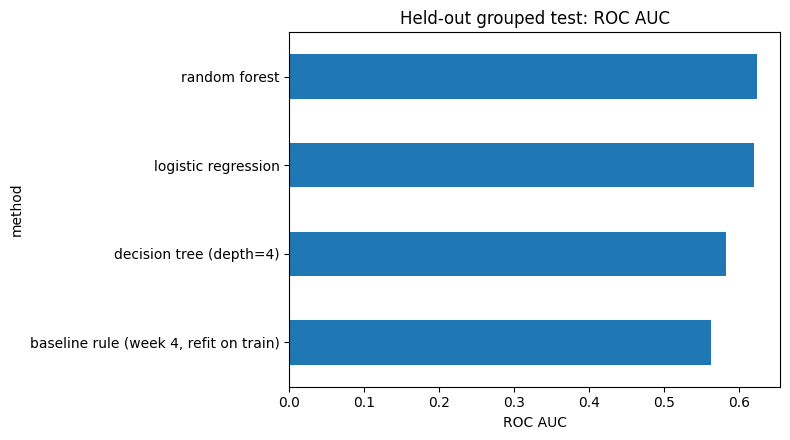

In [4]:
# Compact diagnostic outputs and reproducible artifacts
tree_proba = tree.predict_proba(X_test)[:, 1]
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False)

print(f"Decision tree: {tree.get_n_leaves()} leaves, {len(np.unique(tree_proba))} unique probabilities")
print("\nTop 10 random-forest features:")
print(importances.head(10).round(4))

feature_table = importances.head(10).rename("importance").reset_index()
feature_table.columns = ["feature", "importance"]
feature_table.to_csv(os.path.join(OUTPUT_DIR, "capstone_feature_importance.csv"), index=False)

# Reproduce the committed result table as a figure.
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = comparison.set_index("method")
plot_df["roc_auc"].sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("ROC AUC")
ax.set_title("Held-out grouped test: ROC AUC")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "capstone_auc.png"), dpi=160)
plt.show()


## 5. Limitations

1. **Proxy target:** `is_declining_label` is an observed trend label, not a direct measure of CTR opportunity. A page can have weak CTR without currently being labeled as declining, and vice versa.
2. **Single snapshot:** the source dataset is a trailing-90-day page snapshot rather than a longitudinal daily panel, so this study does not establish temporal forecasting performance.
3. **Grouped holdout:** the test is intentionally restricted to unseen clients. That is a stronger generalization check than a row-level split, but it also means performance can vary with the mix of clients.
4. **Sparse pages:** the clearest false negatives have only 1–2 impressions in 90 days. There is too little exposure information to make a reliable judgment.
5. **No causal claim:** the model ranks observed patterns. It does not show that changing titles, content, freshness, or position will cause traffic to improve.
6. **Public-safe scope:** identifiers are used only for grouping or analysis bookkeeping; client-identifying details are not used in the paper.


## 6. Ranked recommendations

**1. Use the random-forest score as a review queue, not an automatic action.** It is the strongest of the tested methods on the same grouped test split.

**2. Keep the Week-4 500-impression floor as an abstention rule.** The most obvious model failures occur at near-zero exposure, where ranking a page is not well supported by evidence.

**3. Start review with pages that combine high model score with meaningful exposure.** The model's leading signals include average position, 90-day impressions, days with impressions, content age, and sessions. These are useful prioritization signals, not causal levers.

**4. Give the editor a reason code before any change.** For example: "high decline score + adequate exposure + weak CTR" is a review cue; it is not a command to rewrite a page.

**Confidence:** moderate for ranking within this dataset and split; low for causal or future-time claims. A future longitudinal evaluation should be used before operational automation.


## 7. Artifacts the paper embeds

The notebook writes:

- `work/outputs/capstone_model_comparison.csv`
- `work/outputs/capstone_feature_importance.csv`
- `work/outputs/capstone_auc.png`

The deployed paper also contains a static summary table so it remains readable even before notebook execution. The numeric headline values below match the committed Week-5 output; re-running the notebook is the authoritative reproducibility check.


In [5]:
# Final artifact summary
artifact_paths = [
    os.path.join(OUTPUT_DIR, "capstone_model_comparison.csv"),
    os.path.join(OUTPUT_DIR, "capstone_feature_importance.csv"),
    os.path.join(OUTPUT_DIR, "capstone_auc.png"),
]
for path in artifact_paths:
    print(("OK   " if os.path.exists(path) else "MISS "), path)


OK    work/outputs\capstone_model_comparison.csv
OK    work/outputs\capstone_feature_importance.csv
OK    work/outputs\capstone_auc.png


## ML-12 — 5-minute demo outline

**0:00–0:45 — Problem.** We need a ranked review queue for pages that may be declining, without pretending the model predicts Google's algorithm.

**0:45–1:30 — Data safety.** Show the independent trend label, the excluded label-window fields, and the client-grouped split.

**1:30–2:30 — Baseline and model.** Explain the Week-4 CTR rule, then compare logistic regression, a depth-4 tree, and random forest.

**2:30–3:30 — Results.** Highlight the 0.559 test base rate, RF ROC AUC 0.623, average precision 0.656, and precision@50 0.760 versus baseline 0.562 / 0.604 / 0.720.

**3:30–4:20 — Errors and interpretation.** Show that the strongest features are plausible exposure/position signals and that sparse 1–2 impression pages create the clearest false negatives.

**4:20–5:00 — Recommendation.** Use the RF score as a human-review queue, retain the exposure floor, and require editorial review before action.


### Social-post cut

Built a public-safe CTR/engagement opportunity scoring capstone using FlyRank's anonymized internship dataset. A client-grouped 70/30 holdout showed the random forest outperforming the transparent Week-4 baseline on ROC AUC (0.623 vs 0.562), average precision (0.656 vs 0.604), and precision@50 (0.760 vs 0.720). The key lesson was not "ML predicts Google": it was that exposure, position, and content-age signals can improve a human review queue when leakage is controlled and sparse pages are allowed to abstain.


### Employer-facing summary

I built an end-to-end, leakage-aware ranking analysis for CTR/engagement opportunity scoring, starting with a transparent baseline and comparing it with three supervised models. The strongest model was a random forest evaluated on a client-grouped holdout, improving ROC AUC from 0.562 for the baseline to 0.623 while remaining public-safe and reproducible. I treated the output as decision support, documented negative results and sparse-data failure modes, and translated the model into a practical review queue rather than making unsupported causal claims.


## Self-check

- [x] Question and decision are explicit.
- [x] Data exclusions and leakage risks are documented.
- [x] Baseline is evaluated on the same grouped test split.
- [x] Test-set base rate is reported beside precision@50.
- [x] Errors and negative results are discussed.
- [x] Recommendations are framed as decision support.
- [x] Reproducible code uses random seed 42 and a client-grouped 70/30 split.
- [x] No client-identifying details are included.
- [x] Deployed paper contains all nine required report sections, including Abstract and data credit.
